# CNN NLP Spam classification

In [1]:
import torch
from torch import nn
from torch.nn import functional as F
import torch.optim as optim
import numpy as np
import pandas as pd

## Data prep

In [2]:
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df.columns = ['label', 'text']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})


In [3]:
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
import re

MAX_SENETCE_LENGTH = 0

corpus = []
y = df['label'].values
for row in df.iterrows():
    df['text'] = df['text'].apply(lambda x: re.sub(r'[^a-zA-Z0-9]', ' ', x))
    data = row[1]['text'].lower().split()

    MAX_SENETCE_LENGTH = max(MAX_SENETCE_LENGTH, len(data))
    for word in data:
        if word in [' ','']:
            print(row,data)
            break
    
    corpus.append(data)

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(corpus, y, test_size=0.2)

In [6]:
word2index = {'<pad>': 0, '<unk>': 1}
idx = 2
X_train_indexed = []
for row in X_train:
    indexed_row = []
    for word in row:
        if word not in word2index:
            word2index[word] = idx
            idx += 1
        indexed_row.append(word2index[word])
    X_train_indexed.append(indexed_row)

In [7]:
X_test_indexed = []
for row in X_test:
    indexed_row = []
    for word in row:
        indexed_row.append(word2index.get(word, word2index['<unk>']))
    X_test_indexed.append(indexed_row)

In [8]:
from sklearn.utils import shuffle

def generate_batch(X, y, batch_size=64, to_shuffle=True, pad=True):
    if to_shuffle:
        X,y = shuffle(X, y)

    num_batches = int(np.ceil(len(X) / batch_size))
    for i in range(num_batches):
        start = i * batch_size
        end = min((i + 1) * batch_size, len(X))
        batch_X = X[start:end]
        batch_y = y[start:end]

        if pad:
            batch_X = [ [0] * (MAX_SENETCE_LENGTH - len(x)) + x for x in batch_X]
        batch_y = np.array(batch_y).reshape(-1, 1).astype(np.float32)
        yield torch.from_numpy(np.array(batch_X)).long(), torch.from_numpy(batch_y)

In [9]:
for x, y in generate_batch(X_train_indexed, y_train, batch_size=2):
    print(x)
    print(y)
    break

tensor([[   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,  

## Model

In [14]:
class CNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes, kernel_sizes, num_filters):
        super(CNN, self).__init__()
        self.V = vocab_size
        self.D = embedding_dim
        self.C = num_classes
        self.embed = nn.Embedding(vocab_size, embedding_dim) 
    # conv layers
        self.conv1 = nn.Conv1d(self.D, kernel_sizes, 3, padding=1)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(kernel_sizes, 2*kernel_sizes, 3, padding=1)
        self.pool2 = nn.MaxPool1d(2)
        self.conv3 = nn.Conv1d(2*kernel_sizes, 4*kernel_sizes, 3, padding=1)
        
        self.fc = nn.Linear(4*kernel_sizes, self.C)
  
    def forward(self, X):
        # embedding layer
        # turns word indexes into word vectors
        out = self.embed(X)
        # note: output of embedding is always
        # (N, T, D)
        # conv1d expects
        # (N, D, T)

        # conv layers
        out = out.permute(0, 2, 1)
        out = self.conv1(out)
        out = F.relu(out)
        out = self.pool1(out)
        out = self.conv2(out)
        out = F.relu(out)
        out = self.pool2(out)
        out = self.conv3(out)
        out = F.relu(out)

        # change it back
        out = out.permute(0, 2, 1)

        # max pool
        out, _ = torch.max(out, 1)

        # final dense layer
        out = self.fc(out)
        return out

In [15]:
print("vocab size: ", len(word2index))
print("max sentence length: ", MAX_SENETCE_LENGTH)

vocab size:  11753
max sentence length:  171


## train loop

Epoch 1/10, Train Loss: 0.0062, Test Loss: 0.0052
Epoch 2/10, Train Loss: 0.0028, Test Loss: 0.0031
Epoch 3/10, Train Loss: 0.0013, Test Loss: 0.0023
Epoch 4/10, Train Loss: 0.0008, Test Loss: 0.0020
Epoch 5/10, Train Loss: 0.0004, Test Loss: 0.0019
Epoch 6/10, Train Loss: 0.0003, Test Loss: 0.0019
Epoch 7/10, Train Loss: 0.0002, Test Loss: 0.0023
Epoch 8/10, Train Loss: 0.0001, Test Loss: 0.0023
Epoch 9/10, Train Loss: 0.0001, Test Loss: 0.0027
Epoch 10/10, Train Loss: 0.0000, Test Loss: 0.0026


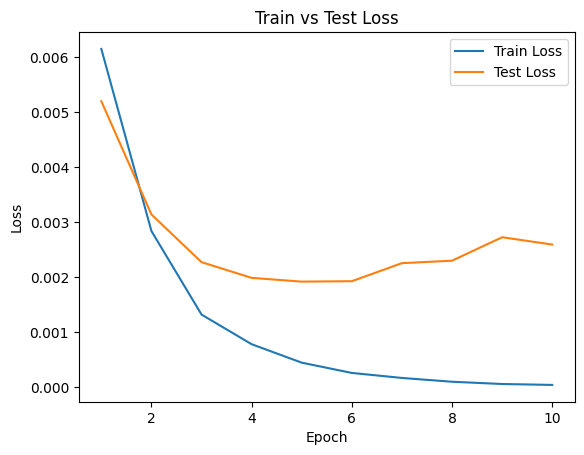

In [16]:
import matplotlib.pyplot as plt

# Hyperparameters
vocab_size = len(word2index)
embedding_dim = 50
num_classes = 1
kernel_sizes = 32
num_filters = 100
num_epochs = 10
learning_rate = 0.001
batch_size = 64

# Initialize model, loss function, and optimizer
model = CNN(vocab_size, embedding_dim, num_classes, kernel_sizes, num_filters)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training and testing loop
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0
    for X_batch, y_batch in generate_batch(X_train_indexed, y_train, batch_size=batch_size):
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    train_losses.append(epoch_train_loss / len(X_train_indexed))

    model.eval()
    epoch_test_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in generate_batch(X_test_indexed, y_test, batch_size=batch_size, to_shuffle=False):
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            epoch_test_loss += loss.item()
    test_losses.append(epoch_test_loss / len(X_test_indexed))

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}")

# Plot losses
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Test Loss')
plt.legend()
plt.show()

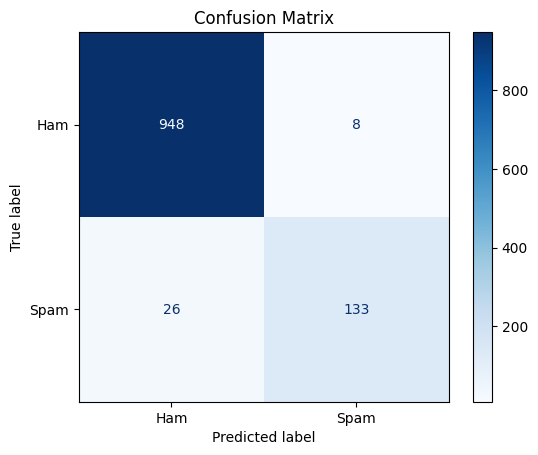

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Set the model to evaluation mode
model.eval()

# Collect predictions and true labels
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in generate_batch(X_test_indexed, y_test, batch_size=batch_size, to_shuffle=False):
        outputs = model(X_batch)
        preds = (torch.sigmoid(outputs) > 0.5).int()
        all_preds.extend(preds.numpy().flatten())
        all_labels.extend(y_batch.numpy().flatten())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()